# ML Unsupervised Algorithms

Group Work + Homework
#### Unsupervised learnign on IRIS data

- for iris dataset (hint: do not forget to preprocess the data):
    - reduce the dimensions to 2 using PCA
    - plot resulting two principal components in a scatter plot and use target labels from iris data to color individual classes
    - analyze how much information (variance) can be attributed to each of the principal components (hint: use the attribute explained_variance_ratio_)
    - use the elbow method to select the optimal number of clusters (assume results of PCA for clustering)
    - perform k-mean clustering with various initiation {‘random', 'k-means++’}
    - plot results of kmeans
    
    - use the target variable to estimate the clustering precision


In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.stats import mode
# in case that you want to use pca package to show PCA properties
!pip install pca
from pca import pca

# in case you want to use programatical way to estimate the number of cluster with elbow method
!pip install kneed
from kneed import KneeLocator
# or use this
from yellowbrick.cluster import KElbowVisualizer



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 4.2 MB/s eta 0:00:00


In [2]:
# load iris dataset
iris = load_iris()
df= pd.DataFrame(data= np.c_[iris['data'], iris['target']],columns= list(iris['feature_names']) + ['target'])
df['target_names'] = iris.target_names[df['target'].astype(int)]
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0,virginica
146,6.3,2.5,5.0,1.9,2.0,virginica
147,6.5,3.0,5.2,2.0,2.0,virginica
148,6.2,3.4,5.4,2.3,2.0,virginica


In [3]:
# Separating out the features
df_X = df.iloc[:,:-2] # remove columns "target" and "target_names"
print(df_X)
X = df_X.values # get only values from dataframe df_X

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [4]:
# Standardizing the features
X_scaled = StandardScaler().fit_transform(X)

In [5]:
# PCA projection to lower dimensional space
pcamodel = PCA(n_components = 2)
principalComponents = pcamodel.fit_transform(X_scaled)

# lets make new dataframe
df_pc = pd.DataFrame(data = principalComponents, columns = ['pc1', 'pc2'])
df_final = pd.concat([df_pc, df[['target']], df[['target_names']]], axis = 1) # just for demo we add the targets
df_final

,pc1,pc2,target,target_names
0,-2.264703,0.480027,0.0,setosa
1,-2.080961,-0.674134,0.0,setosa
2,-2.364229,-0.341908,0.0,setosa
3,-2.299384,-0.597395,0.0,setosa
4,-2.389842,0.646835,0.0,setosa
...,...,...,...,...
145,1.870503,0.386966,2.0,virginica
146,1.564580,-0.896687,2.0,virginica
147,1.521170,0.269069,2.0,virginica
148,1.372788,1.011254,2.0,virginica


<Axes: xlabel='pc1', ylabel='pc2'>

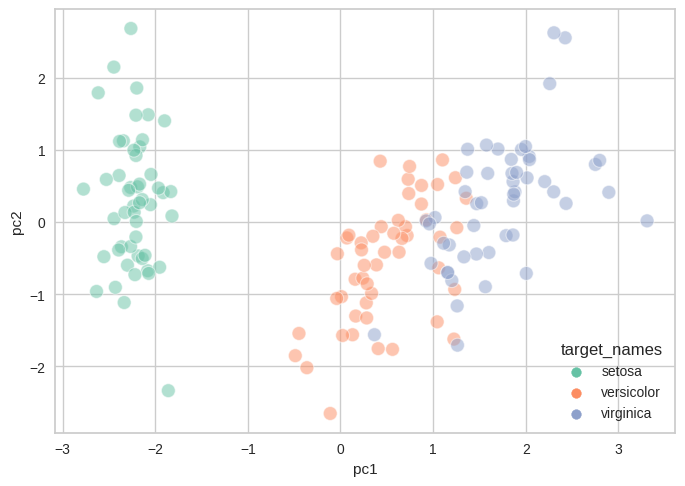

In [6]:
# plot results of PCA
sns.set_palette('Set2')
sns.scatterplot(x= 'pc1', y='pc2', hue='target_names', data=df_final, alpha=0.5, s=100)


In [7]:
# how much variance is actually explained by 2 principal components?
print(pcamodel.explained_variance_ratio_)
print('explained variance {:0.2f}%'.format(100*sum(pcamodel.explained_variance_ratio_)))

[0.72962445 0.22850762]
explained variance 95.81%


[pca] >Column labels are auto-completed.
[pca] >Row labels are auto-completed.
[pca] >The PCA reduction is performed on the [4] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[3]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]
[pca] >Plot PC1 vs PC2 with loadings.


[scatterd] >INFO> Create scatterplot
[scatterd] >INFO> Create scatterplot


[pca] >Plot PC1 vs PC2 vs PC3 with loadings.


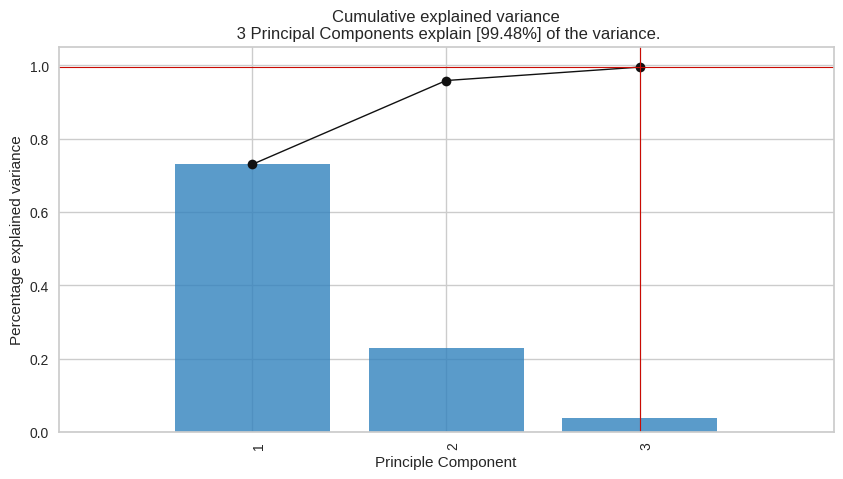

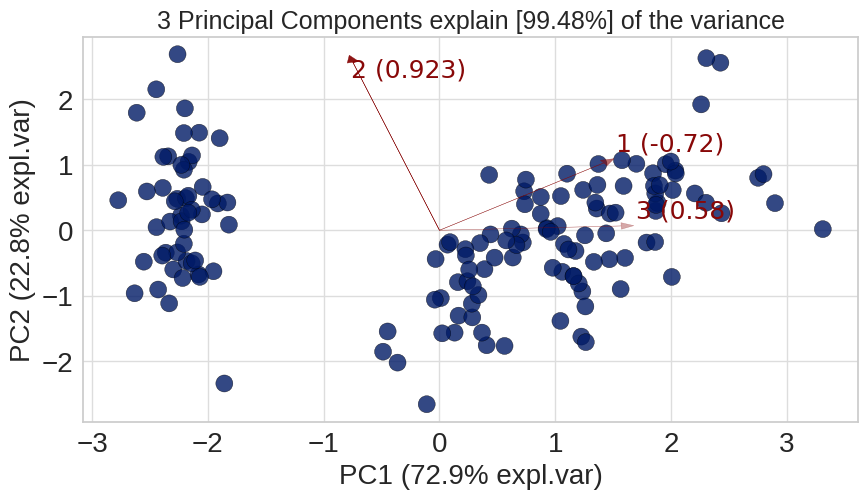

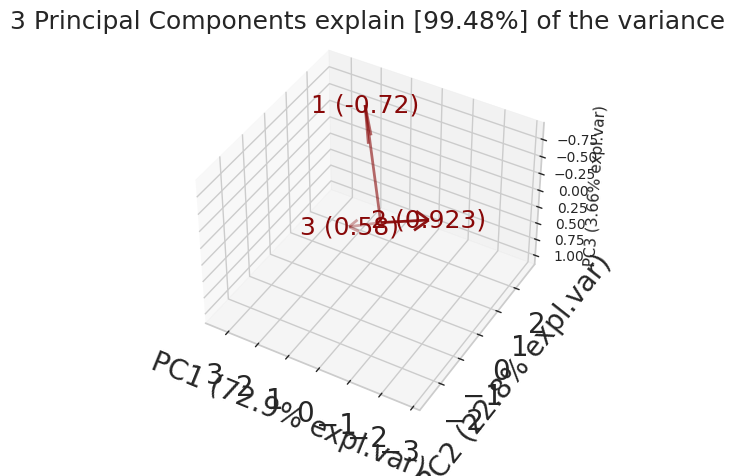

In [8]:
# anotehr way of performing PCA and its visualization
model = pca(n_components=3)
results = model.fit_transform(X_scaled)

# Plot explained variance
fig, ax = model.plot(figsize=(10,5))
# Make biplot with the number of features
fig, ax = model.biplot(n_feat=3, legend=True, figsize=(10,5))
fig, ax = model.biplot3d(n_feat=3, cmap=None, legend=True, figsize=(8,5))

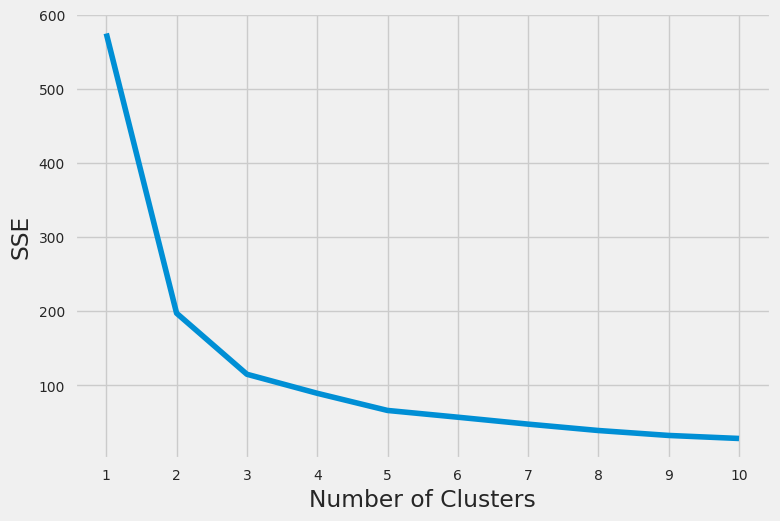

In [9]:
# determining b=number of cluster by elbow method
kmeans_kwargs = {
  "init": 'k-means++',
  "n_init": 20,
  "max_iter": 100,
  "random_state": 10,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
  kmeans.fit(df_pc)
  sse.append(kmeans.inertia_)
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()
# we can visually see that the curve has break point at either 2 or 3 cllusters

In [10]:
# an automatic way to select nmebr of clusters based on computed SSE
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
print('We will select {} clusters'.format(kl.elbow))

We will select 3 clusters


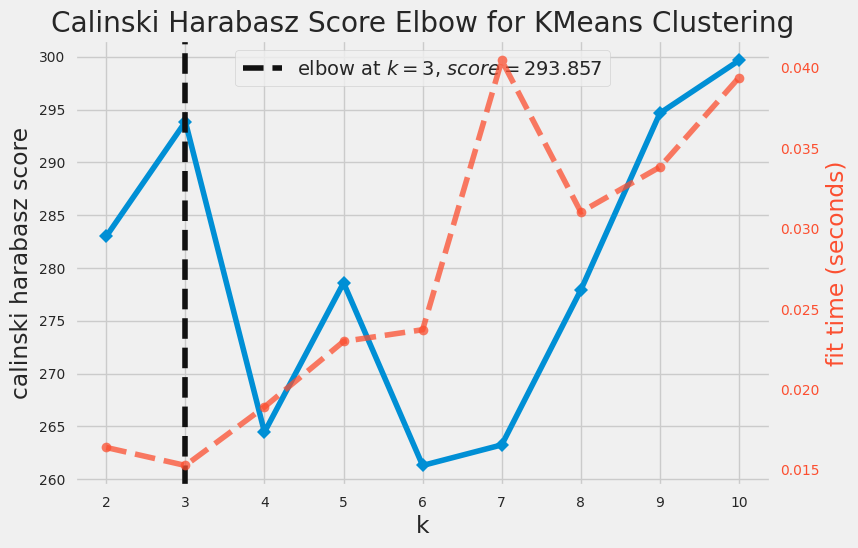

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [11]:

from yellowbrick.cluster import KElbowVisualizer # here we import KElbowVisualizer
# k is range of number of clusters.
visualizer = KElbowVisualizer(kmeans, k=10, metric='calinski_harabasz', timings= True)
visualizer.fit(df_pc)
visualizer.show()    # Fit data to visualizer

In [12]:
# perform kmeans clustering fro different init methods
methods = ['k-means++', 'random']

number_clusters = kl.elbow

kmeans = []
for method in methods:
  kmeans_kwargs = {
    "init": method,
    "n_init": 20,
    "max_iter": 100,
    "random_state": 10,
  }
  kmeans.append(KMeans(n_clusters=number_clusters, **kmeans_kwargs))

In [13]:
print(kmeans)

[KMeans(max_iter=100, n_clusters=3, n_init=20, random_state=10), KMeans(init='random', max_iter=100, n_clusters=3, n_init=20, random_state=10)]


In [14]:
# fit models with both init methods
clusters_random_method = kmeans[1].fit_predict(df_pc) # Compute cluster centers and predict cluster index for each sample
clusters_kmeans_method = kmeans[0].fit_predict(df_pc) # Compute cluster centers and predict cluster index for each sample

In [15]:
print(clusters_random_method)
print(clusters_kmeans_method)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1
 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0 1
 1 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


<Axes: xlabel='pc1', ylabel='pc2'>

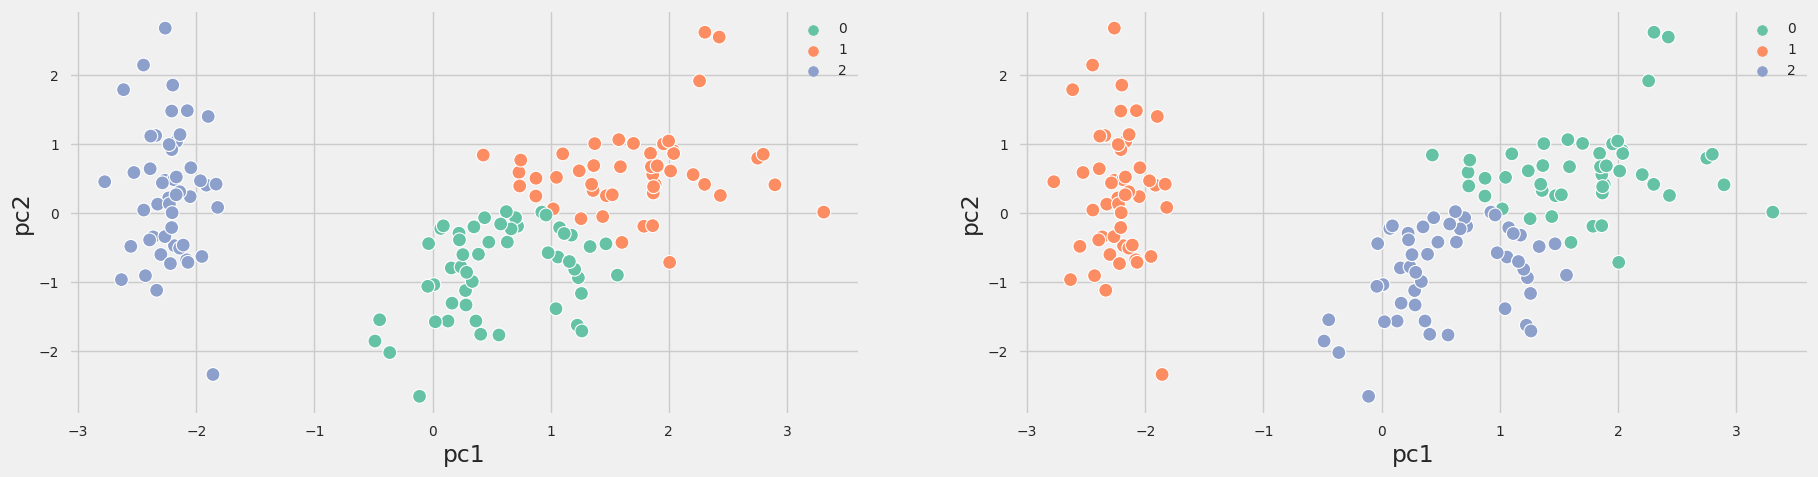

In [16]:
# plot results of kmeans
fig, axs = plt.subplots(1, 2, figsize = (20, 5))

sns.scatterplot(x = 'pc1', y ='pc2', hue = clusters_random_method, data=df_pc, ax = axs[0], s=100, palette="Set2")

sns.scatterplot(x = 'pc1', y ='pc2', hue = clusters_kmeans_method, data=df_pc, ax = axs[1], s=100, palette="Set2")

# results look similar or the same, but the cluster label is different per init method

In [17]:
# we use the target variable to check the accuracy of clustering
targets = df['target'].values.astype(int)
print(kmeans[0].cluster_centers_.shape)
print(kmeans[1].cluster_centers_.shape)

(3, 2)
(3, 2)


In [18]:
print("result labels and targets - # !!! labels or data annotation do not correspond to target variable")

# for random init
print(*kmeans[0].labels_)
print(*targets)

# for kmeans++ init
print(*kmeans[1].labels_)
print(*targets)

# !!! labels or data annotation do not correspond to target variable

result labels and targets - # !!! labels or data annotation do not correspond to target variable
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0 0 2
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0
0 0

In [19]:
from scipy.stats import mode

def get_clusterlabels(clusters, number_clusters):
  labels = np.zeros_like(clusters)
  for i in range(number_clusters):
      mask = (clusters == i) # for each digit we mask the data and focus only on one digit per one loop
      # print(*targets[mask])
      # print(*mask)
      # print(*targets[mask].shape)
      # print(*mask.shape)
      labels[mask] = mode(targets[mask])[0] # I am assgning the most common value to the variable labels at the index positions defined by mask
      print('cluster number', i, ', most common valus in the cluster', *[mode(targets[mask])[0]])
  return labels

In [20]:
number_clusters

3

In [21]:
# get proper labels for random initialization
labels_random = get_clusterlabels(clusters_random_method, number_clusters)
print(labels_random)

cluster number 0 , most common valus in the cluster 1
cluster number 1 , most common valus in the cluster 2
cluster number 2 , most common valus in the cluster 0
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 2 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


In [22]:
# get proper labels for random initialization
labels_kmeans = get_clusterlabels(clusters_kmeans_method, number_clusters)
print(labels_kmeans)

cluster number 0 , most common valus in the cluster 2
cluster number 1 , most common valus in the cluster 0
cluster number 2 , most common valus in the cluster 1
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 2 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


In [23]:
print(iris['target_names'])
print(df_pc)

['setosa' 'versicolor' 'virginica']
          pc1       pc2
0   -2.264703  0.480027
1   -2.080961 -0.674134
2   -2.364229 -0.341908
3   -2.299384 -0.597395
4   -2.389842  0.646835
..        ...       ...
145  1.870503  0.386966
146  1.564580 -0.896687
147  1.521170  0.269069
148  1.372788  1.011254
149  0.960656 -0.024332

[150 rows x 2 columns]


<Axes: xlabel='pc1', ylabel='pc2'>

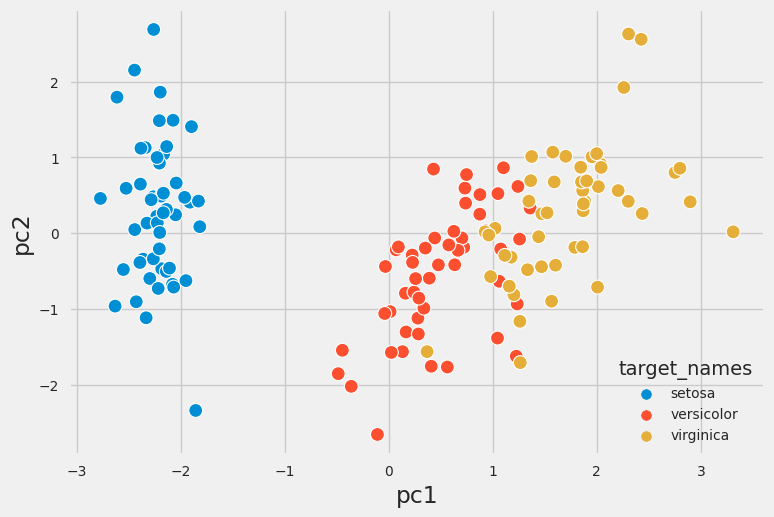

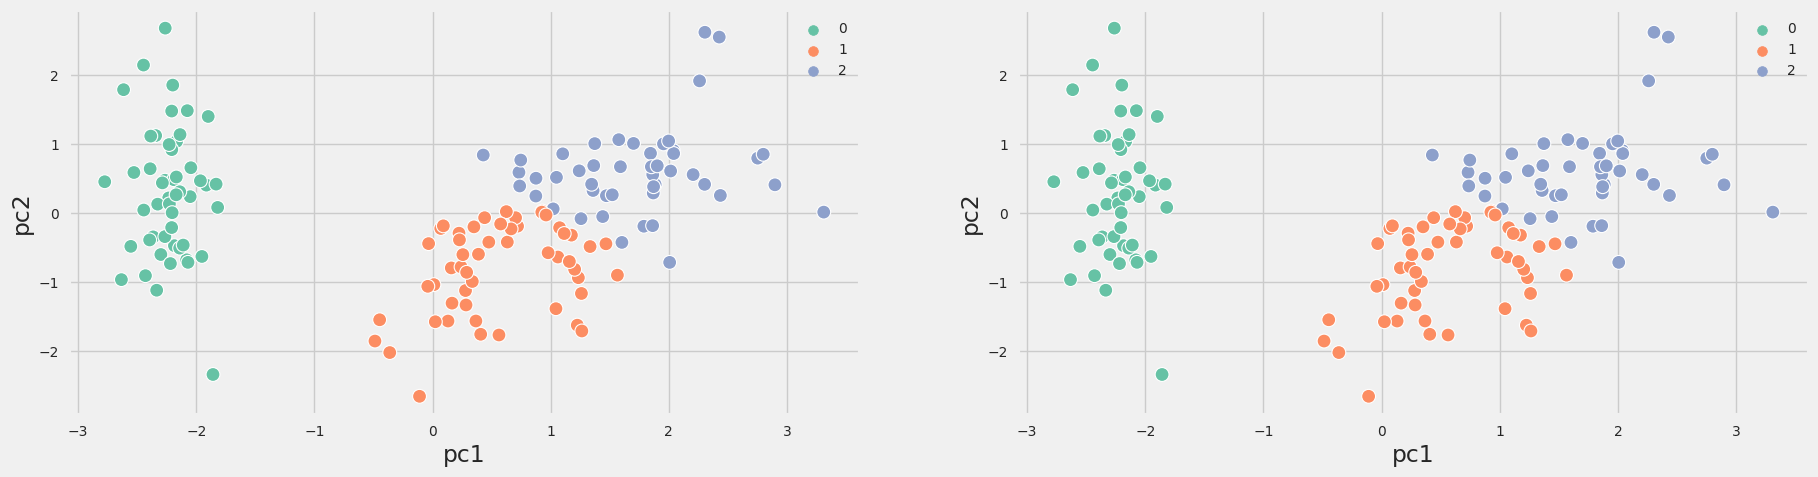

In [24]:
# plot results of kmeans with correct labels
sns.scatterplot(x= 'pc1', y='pc2', hue='target_names', data=df_final, s=100)

fig, axs = plt.subplots(1, 2, figsize = (20, 5))

sns.scatterplot(x = 'pc1', y ='pc2', hue = labels_random, data=df_pc, ax = axs[0], s=100, palette="Set2")

sns.scatterplot(x = 'pc1', y ='pc2', hue = labels_kmeans, data=df_pc, ax = axs[1], s=100, palette="Set2")

<Axes: xlabel='pc1', ylabel='pc2'>

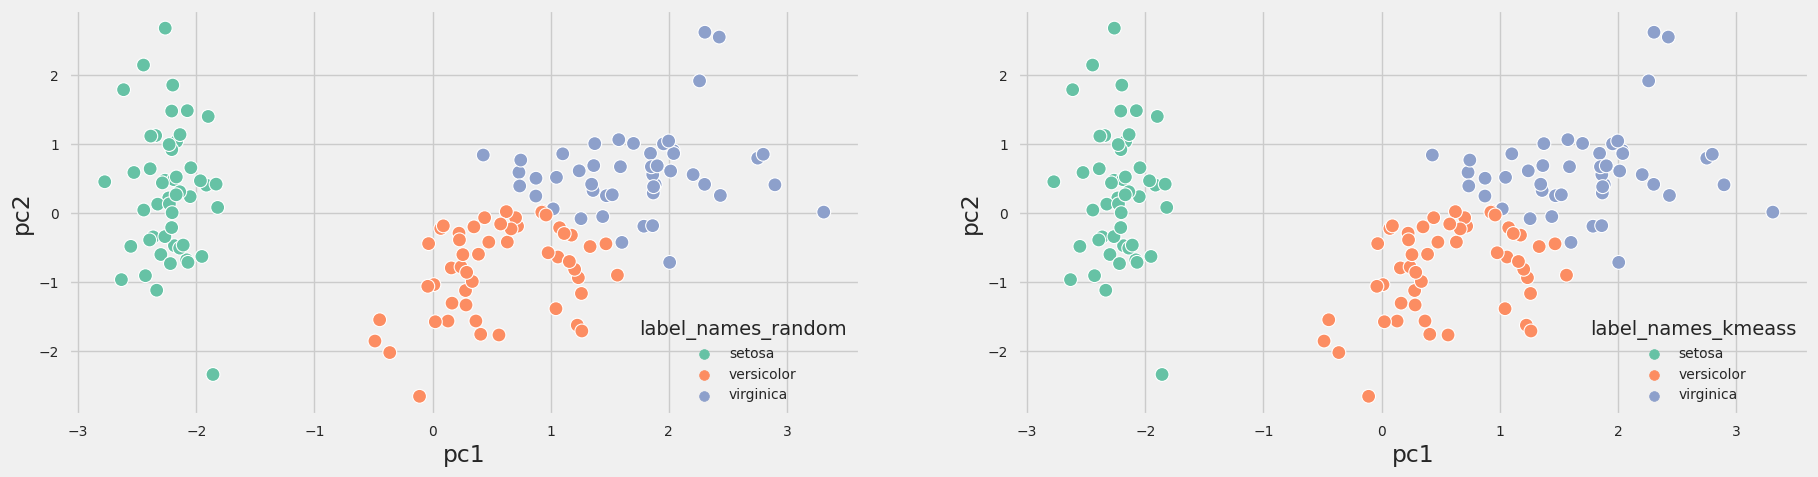

In [25]:
# again plot it with target names
fig, axs = plt.subplots(1, 2, figsize = (20, 5))
df_pc['label_names_random'] = iris['target_names'][labels_random]
df_pc['label_names_kmeass'] = iris['target_names'][labels_kmeans]

hue_order = iris['target_names']
sns.scatterplot(x = 'pc1', y ='pc2', hue = 'label_names_random', hue_order=hue_order, data=df_pc, ax = axs[0], s=100, palette="Set2")
sns.scatterplot(x = 'pc1', y ='pc2', hue = 'label_names_kmeass', hue_order=hue_order, data=df_pc, ax = axs[1], s=100, palette="Set2")

In [26]:
# compute the accuracy between labels(i.e. cluster) and target variable
# this is only for educational purposis and understanding clustering mechanisms, in practive you will not have an information about target variable
from sklearn.metrics import accuracy_score
print(accuracy_score(targets, labels_random))
print(accuracy_score(targets, labels_kmeans))

0.8333333333333334
0.8333333333333334


In [27]:
from sklearn.metrics import cohen_kappa_score # expresses the level of agreement between two annotators on a classification problem
print(cohen_kappa_score(targets, labels_random))
print(cohen_kappa_score(targets, labels_kmeans))

0.75
0.75


In [28]:
# this is how to mount google drive to be usable and reachable as data storage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
# convert colab nb to html
%%shell
jupyter-nbconvert --to html /content/drive/MyDrive/Teaching/MLP/2023_autumn/W3-Solutions.ipynb


[NbConvertApp] Converting notebook /content/drive/MyDrive/Teaching/MLP/2023_autumn/W3-Solutions.ipynb to html
[NbConvertApp] Writing 1756699 bytes to /content/drive/MyDrive/Teaching/MLP/2023_autumn/W3-Solutions.html
